# Dynamics Python Labs
### Created by Cait Roufa

### Lab 4 - Kinematics
In this lab, we will explore the kinematics of horizontal wind fields. Kinematics describes the motion of the atmosphere without considering the forces that cause it. By working with real-world reanalysis data, you will calculate divergence, vorticity, stretching deformation, and shearing deformation, and analyze how these quantities relate to the streamline patterns of the flow.

#### Learning Objectives
1. Import and preprocess gridded wind data.
2. Compute horizontal wind derivatives for divergence, vorticity, and shearing and stretching deformation.
3. Interpret horizontal flow patterns.

In [1]:
# import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
from metpy.units import units

#### Step 1: Data Setup
We've selected the wind field for the March 31, 2023 US severe weather outbreak.

In [2]:
# OPeNDAP URLs for 6-hourly data (2023)
url_u = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/uwnd.2023.nc"
url_v = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/vwnd.2023.nc"

# Open datasets
ds_u = xr.open_dataset(url_u)
ds_v = xr.open_dataset(url_v)

# Select 500 hPa winds for March 31, 2023 at 00Z
u = ds_u['uwnd'].sel(level=500, time="2023-03-31T00:00:00") * units('m/s')
v = ds_v['vwnd'].sel(level=500, time="2023-03-31T00:00:00") * units('m/s')

lats = ds_u['lat']
lons = ds_u['lon']

/home/croufa/.local/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.26.0
  warnings.warn(


#### Step 2: Calculate Kinematic Values
Now we need to calculate the divergence, vorticity, and deformation using the input wind components.

In [3]:
# calculate dx and dy
dx, dy = mpcalc.lat_lon_grid_deltas(lons.values, lats.values)

# divergence
div = mpcalc.divergence(u, v, dx=dx, dy=dy)

# relative vorticity
vort = mpcalc.vorticity(u, v, dx=dx, dy=dy)

# deformation
stretch_def = mpcalc.stretching_deformation(u, v, dx=dx, dy=dy)
shear_def   = mpcalc.shearing_deformation(u, v, dx=dx, dy=dy)
total_def   = np.sqrt(stretch_def**2 + shear_def**2)

/anaconda3/envs/pyEAE/lib/python3.9/site-packages/pint/quantity.py:1313: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


#### Step 3: Plot
Now we can plot the divergence, vorticity, deformation, and streamlines.

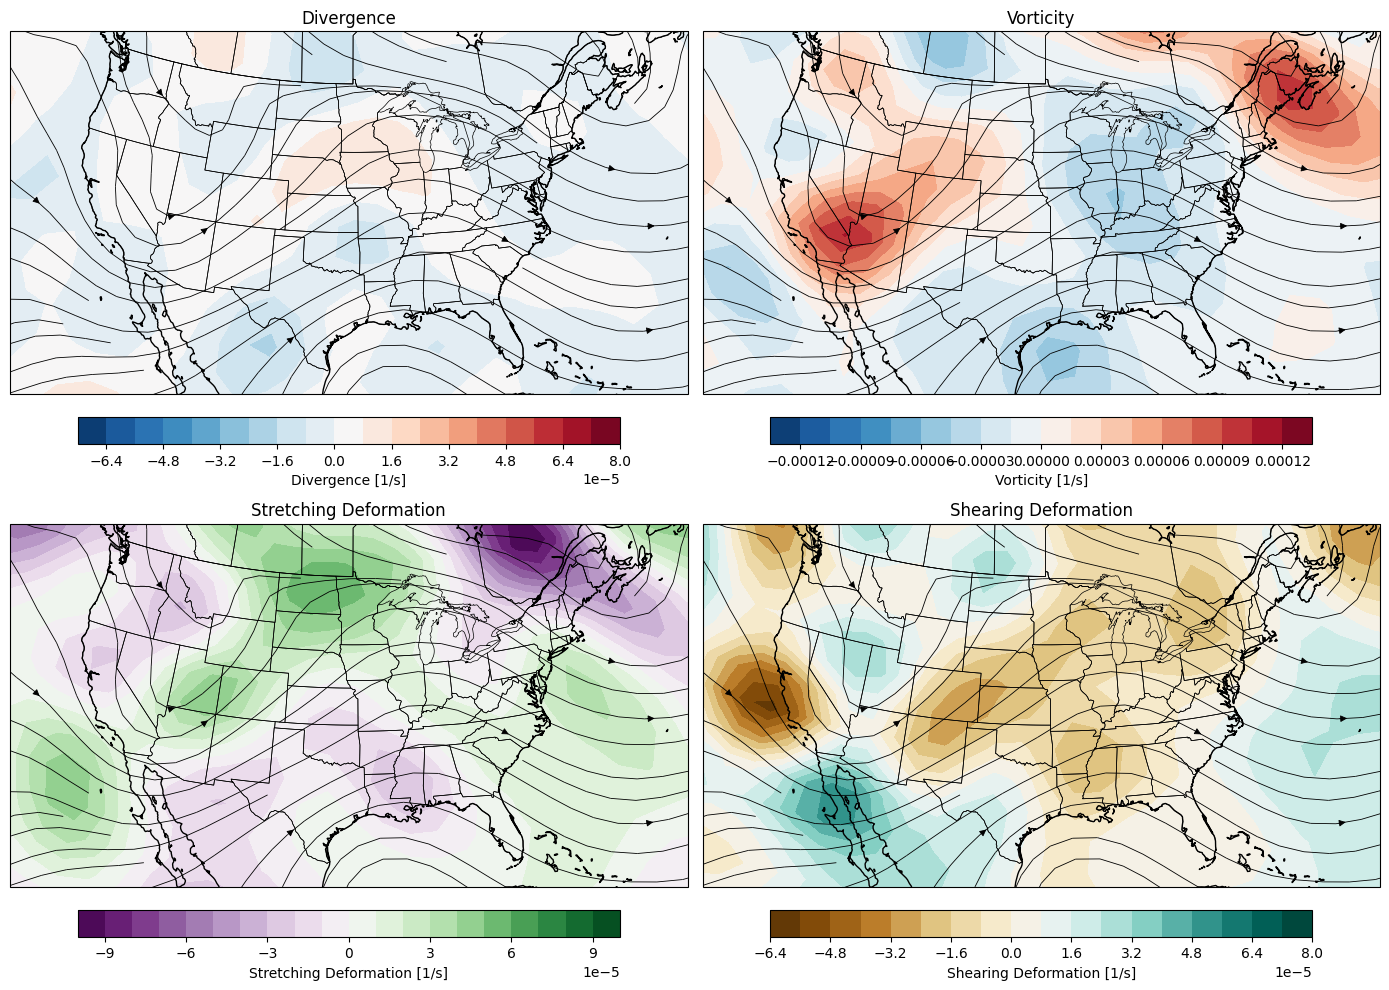

In [4]:
# set map projection
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=35)

# set up subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10),
                        subplot_kw={'projection': proj})

# define fields to plot and colormaps
fields = [
    (div, "Divergence", 'RdBu_r'),
    (vort, "Vorticity", 'RdBu_r'),
    (stretch_def, "Stretching Deformation", 'PRGn'),
    (shear_def, "Shearing Deformation", 'BrBG')
]

for ax, (field, title, cmap) in zip(axs.flat, fields):
    cs = ax.contourf(
        lons, lats, field.values, 21, cmap=cmap,
        transform=ccrs.PlateCarree()
    )

    # plot streamlines
    ax.streamplot(
        lons.values, lats.values, u.values, v.values,
        transform=ccrs.PlateCarree(),
        density=5.0,  # increase for more streamlines
        color='k', linewidth=0.6
    )

    # plot map features
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)

    # add colorbar with units
    cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    try:
        units_str = f"[{field.metpy.units:~P}]"
    except Exception:
        units_str = ""
    cbar.set_label(f"{title} {units_str}")

plt.tight_layout()
plt.show()

#### Questions

1. In your plot, identify regions of strong divergence. How do you know these areas have strong divergence?
2. Does your plot represent streamlines or trajectories?
3. Where are the maxima of positive vorticity? Do these align with cyclonic curvature in the streamlines?
4. Compare the patterns of stretching vs. shearing deformation. Which dominates in this case study?
5. Describe areas of confluence (streamlines coming together) and diffluence (streamlines spreading apart). How do these compare to speed divergence?

### Challenge!
Select a different date (e.g., a major storm or event) and repeat the analysis with new data. Compare your kinematic fields with the streamline patterns. How do the dynamics differ from our first case?

In [5]:
# step 1: load data

In [6]:
# step 2: calculate kinematic values

In [7]:
# step 3: plot

Answer the same questions as above.